In [1]:
import torch

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from itertools import cycle
from functools import partial
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso

from src.io import load_data
from src.feature import variance_feature, annotate_labels, our_feature
from src.learning import random_fit_and_eval, RMSE, MAPE
from src.utils import (
    diff_cycles,
    savgol_smooth, 
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar,
    nankurtosis,
)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator

# --- customise matplotlib to Nature defaults -------------------------------
plt.rcParams.update({
    "figure.figsize": (90/25.4, 65/25.4),   # width, height in inches
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica, Arial",
    "font.size": 7,                         # ≥7 pt everywhere
    "axes.linewidth": 0.5,
    "axes.labelsize": 7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


In [2]:
data_folder = '/data/raw'
data = load_data(data_folder)


Loading cells:   0%|          | 0/151 [00:00<?, ?it/s]

Loading cells: 100%|██████████| 151/151 [17:47<00:00,  7.07s/it]


In [ ]:
data = dict(sorted(data.items()))  

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

In [3]:
scores = {}
seeds = list(range(16))  # Randomness for dataset split and model initialization
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
num_early_cycles = 50

smoother = partial(savgol_smooth, window=51, order=3)

In [4]:
import pandas as pd
mdcs = pd.read_csv('/data/mdcs.csv')
mdcs['name'] = mdcs['tags'].apply(lambda x: x.split('~')[1])
mdc_dict = mdcs.set_index('name')['mdcs'].to_dict()  


In [5]:
device = 'cpu'
y = torch.tensor([mdc_dict[cell_name] for cell_name, label in relative_labels.items() if label > num_early_cycles])
X = torch.stack([
    torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ])
        for cycle_data in data[cell][:50]
    ]) for cell, label in relative_labels.items() if label > num_early_cycles
]).permute(0, 2, 1, 3).contiguous()

In [6]:
from sklearn.linear_model import Lasso
from src.feature import our_feature
X_ours, feature_names = our_feature(
    X,
    num_cycle_groups=5,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name=True,
    device='cpu'
)
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)

In [7]:
import random
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

threshold = 0.0005
y_binary = np.where(y <= threshold, 0, 1)

seed = 0
train_frac = 0.7
set_seed(seed)

# Random train-test split
N = int(train_frac * len(X_ours))
perm = np.random.permutation(len(X_ours))
X_train, X_test = X_ours[perm[:N]], X_ours[perm[N:]]
y_train, y_test = y_binary[perm[:N]], y_binary[perm[N:]]

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=0)

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score  
# Get the predicted probabilities for the positive class  
y_probs = clf.predict_proba(X_test)[:, 1]  
  
# Calculate AUROC  
auroc = roc_auc_score(y_test, y_probs)  
print(f'AUROC: {auroc}')  
  
# Calculate AUCPR  
aucpr = average_precision_score(y_test, y_probs)  
print(f'AUCPR: {aucpr}')

AUROC: 0.9868421052631579
AUCPR: 0.9769230769230769


## Generate feature importance

In [11]:
fea_masks = clf.feature_importances_ != 0
fea_importance = []
# Get feature importances  
importances = clf.feature_importances_  
nonzero_fea_idxs = np.where(fea_masks)[0]
# Sort the feature importances in descending order  
sorted_indices = np.argsort(importances)[::-1]  
top_sorted_indices = sorted_indices[:20]

for i, idx in enumerate(top_sorted_indices):  
    print(i, feature_names[idx])
    fea_importance.append([feature_names[idx], importances[idx]])
fea_imp_mdc = pd.DataFrame(data=fea_importance, columns=[ 'feature_name', 'score'])
fea_imp_mdc['seed'] = 0
fea_imp_mdc.to_csv('/results/feature_importance_kneepoint.csv')

0 identity(nanvar(Cycle(1/5) - Cycle(3/5))[nanmax(VQ_d(1/4))])
1 abs(nanmean(Cycle(1/5))[nanmean(Qdlinear(3/4))])
2 identity(nanmean(Cycle(1/5) - Cycle(5/5))[nanvar(VQ_d(4/4))])
3 identity(nanmax(Cycle(1/5))[nanmean(VQ_d(3/4))])
4 identity(nanvar(Cycle(1/5) - Cycle(2/5))[nanmax(VQ_d(1/4))])
5 identity(nanmean(Cycle(1/5))[nankurtosis(E_c(1/4))])
6 identity(nanmin(Cycle(2/5))[nanmin(V_d(3/4))])
7 abs(nanmax(Cycle(1/5))[nanmax(VQ_c(2/4))])
8 abs(nanmean(Cycle(4/5))[nanvar(VQ_d(1/4))])
9 identity(nanmean(Cycle(3/5))[nanskew(VQ_d(1/4))])
10 abs(nanmax(Cycle(4/5) - Cycle(5/5))[nanvar(Qclinear(2/4))])
11 identity(nanmean(Cycle(1/5))[nanmean(dVdQ_d(3/4))])
12 identity(nanmax(Cycle(5/5))[nanmin(VQ_c(2/4))])
13 identity(nanvar(Cycle(3/5))[nanmin(Qclinear(1/4))])
14 abs(nanmax(Cycle(4/5))[nanmin(VQ_c(2/4))])
15 identity(nanmin(Cycle(2/5))[nanmax(V_d(3/4))])
16 identity(nanmean(Cycle(2/5) - Cycle(5/5))[nanmin(VQ_c(4/4))])
17 identity(nanmax(Cycle(2/5) - Cycle(3/5))[nanmin(VQ_c(2/4))])
18 identity(

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap, ListedColormap  
from sklearn.ensemble import RandomForestClassifier

def plot_tsne_figure(X_train, X_test, y_train, y_test, y_probs, mask_font=False, save_fig_path = None):
    # save_fig_path = '../output/3d.svg'
    
    # Combine train and test data for t-SNE
    combined_x = np.vstack((X_train, X_test))
    combined_y = np.hstack((y_train, y_probs))

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(combined_x)

    # Split t-SNE results back into train and test
    tsne_train = tsne_results[:len(X_train)]
    tsne_test = tsne_results[len(X_train):]

    # Plot the results
    plt.figure(figsize=(10, 8))
    unique_classes = np.unique(combined_y)

    colors = plt.cm.get_cmap('coolwarm', len(unique_classes))

    color_mapping = {label: colors(i) for i, label in enumerate(unique_classes)}
    cmap = ListedColormap([color_mapping[label] for label in unique_classes])
    color1 = '#4473c5'  # Side color 1  
    color2 = '#c55b11'  # Side color 2 
    custom_cmap = LinearSegmentedColormap.from_list('custom_coolwarm', [color1, color2], N=len(unique_classes))

    if mask_font:
        train_label = ' ' * 20
        test_label = ' ' * 20
        
    else:
        train_label = 'Train'
        test_label = 'Test'

    plt.scatter(tsne_train[:, 0], tsne_train[:, 1], c=y_train, cmap=cmap, alpha=0.6, marker='x', label=train_label, s=80)
    scatter = plt.scatter(tsne_test[:, 0], tsne_test[:, 1], c=y_probs, cmap=cmap, alpha=0.6, marker='o', label=test_label, s=80)


    # plot decision boundary and background 
    cbar = plt.colorbar(scatter, ticks=range(len(unique_classes)))
    cbar.set_ticklabels('')



    combined_y = np.hstack((y_train, y_test))
    # Train Random Forest classifier on the t-SNE transformed data
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(tsne_results, combined_y)

    # Create a grid of points to predict labels
    xx, yy = np.meshgrid(np.linspace(tsne_results[:, 0].min() - 1, tsne_results[:, 0].max() + 1, 500),
                        np.linspace(tsne_results[:, 1].min() - 1, tsne_results[:, 1].max() + 1, 500))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)


    # Plot the decision boundary by assigning a color to each point in the mesh
    plt.contourf(xx, yy, Z, alpha=0.1, cmap='coolwarm')


    # plt.legend(fontsize=16)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.title('t-SNE Visualization of Training and Testing Data')

    if mask_font:
        plt.title('')
        plt.xlabel('')
        plt.ylabel('')
        plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
        plt.tick_params(axis='y', which='both', left=True, right=False, labelleft=False)
    else:
        plt.legend()


    if save_fig_path:
        fig_format = save_fig_path.split('.')[-1]
        plt.savefig(save_fig_path, format=fig_format)
        
    plt.show()


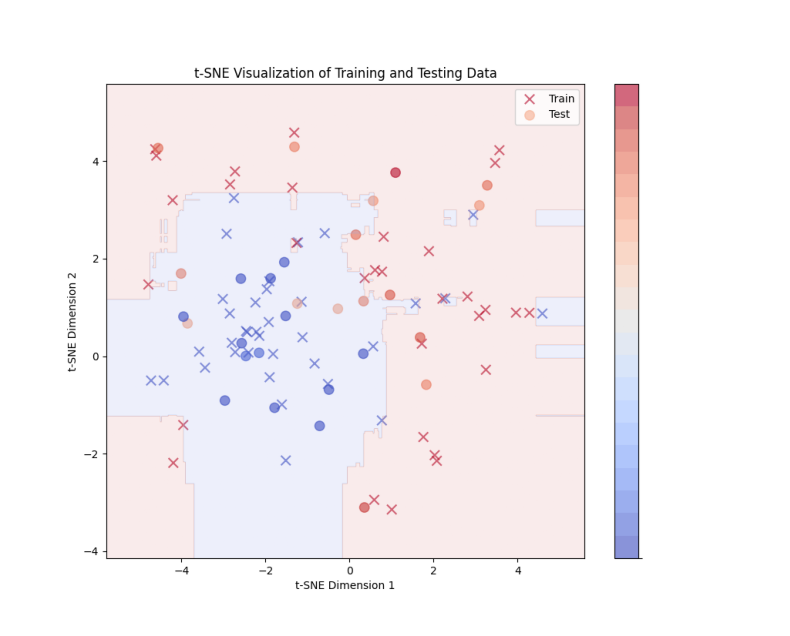

In [14]:
# plot_tsne_figure(X_train, X_test, y_train, y_test, y_probs, save_fig_path = '/results/3c.svg', mask_font=False)
plot_tsne_figure(X_train, X_test, y_train, y_test, y_probs, save_fig_path = '/results/3c.png')